# Consolidated figures — sym_pt (Liu-extension)
Reported values/stars read from `stats_results.csv`. Run top to bottom.

**Two cells need prerequisite code pasted above them** (marked) — the stacked-WTA and Procrustes cells depend on `wta_data`/`TFCE_DIR` and `subj_mats`/`stratum`/`coords`/`HEMIS`/`df` respectively, which aren't in this notebook yet.

**Corrections applied.** `EXCLUDE` now carries all six exclusions (cells 2 and 25 — it previously held only `sub-017`, so every filtering cell ran on a larger cohort than the reported stats). `plot_primary_panel` no longer falls back to `ctrl_le`/`pt_le`. House parcel is set once via `HOUSE_ROI`. Superseded scratch cells removed.


## 1. Setup & paths

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
STATS_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results_harmonized_corrected.csv')
UNIVAR_HARM = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized.csv')
RSA_HARM    = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017', 'sub-091', 'sub-095', 'sub-096', 'sub-027', 'sub-084']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CATEGORIES = ['face', 'house', 'object', 'word']

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')

LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact


## 2. Load data — `ctrl_le`, `pt_le`, `ctrl_subs`, `otc_subs`

In [2]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls -> first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients -> last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())
print(f'Controls: {len(ctrl_subs)}   OTC patients: {len(otc_subs)}')

Controls: 34   OTC patients: 21


In [3]:
# Harmonized per-measure frames for the sum-sel & distinctiveness panels.
# Same exclusion + session rule as the cell above (controls=first, OTC=last).
# sum-selectivity -> univariate_v1_harmonized (sum_selec_norm)
# distinctiveness -> rsa_v1_harmonized       (liu_distinctiveness)
def _load_harmonized(path):
    d = pd.read_csv(path)
    d = d[~d['subject_id'].isin(EXCLUDE)]
    d['ses_num'] = pd.to_numeric(d['session'], errors='coerce').astype(int)
    for bad_sub, bad_ses in EXCLUDE_SES:
        d = d[~((d['subject_id'] == bad_sub) & (d['ses_num'] == bad_ses))]
    if 'pair' in d.columns:                      # rsa is long by pair; collapse
        d = d.drop(columns=['pair', 'fisher_r']).drop_duplicates()
    ctrl = d[d['status'] == 'control']
    fs = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
    ctrl = ctrl.merge(fs, on='subject_id'); ctrl = ctrl[ctrl['ses_num'] == ctrl['keep']].drop(columns='keep')
    pt = d[d['group'] == 'OTC']
    ls = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
    pt = pt.merge(ls, on='subject_id'); pt = pt[pt['ses_num'] == pt['keep']].drop(columns='keep')
    return ctrl, pt

ctrl_uni, pt_uni = _load_harmonized(UNIVAR_HARM)   # sum_selec_norm
ctrl_rsa, pt_rsa = _load_harmonized(RSA_HARM)      # liu_distinctiveness
print(f'univar harmonized: {ctrl_uni.subject_id.nunique()} ctrl / {pt_uni.subject_id.nunique()} OTC')
print(f'rsa    harmonized: {ctrl_rsa.subject_id.nunique()} ctrl / {pt_rsa.subject_id.nunique()} OTC')

# Cohort check against stats_results_harmonized_corrected.csv (36 / 12 / 12).
for _nm, _d in [('ctrl_uni', ctrl_uni), ('pt_uni', pt_uni),
                ('ctrl_rsa', ctrl_rsa), ('pt_rsa', pt_rsa)]:
    _n = _d['subject_id'].nunique()
    _by = _d.groupby('intact_hemi')['subject_id'].nunique().to_dict() \
        if 'intact_hemi' in _d.columns else {}
    print(f'{_nm:9s} n={_n:3d}  {_by}')
print('note: univariate_v1_harmonized.csv holds fewer controls than '
      'rsa_v1_harmonized.csv; peak/selectivity panels inherit that n')


univar harmonized: 34 ctrl / 24 OTC
rsa    harmonized: 36 ctrl / 24 OTC
ctrl_uni  n= 34  {'control': 34}
pt_uni    n= 24  {'left': 12, 'right': 12}
ctrl_rsa  n= 36  {'control': 36}
pt_rsa    n= 24  {'left': 12, 'right': 12}
note: univariate_v1_harmonized.csv holds fewer controls than rsa_v1_harmonized.csv; peak/selectivity panels inherit that n


## 3. Peak coordinates (MNI) — Fig 4
Reads `peak_coords_mni.csv`. House parcel = `house_PPA_strict` here (intentional for peak).

In [4]:
# 3a. MNI peak-coord machinery (prereq for 3b)
from matplotlib.patches import Ellipse
import matplotlib.transforms as mtransforms

MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)

mni = pd.read_csv(MNI_CSV)
mni = mni[~mni['subject_id'].isin(EXCLUDE)]
mni['ses_num'] = pd.to_numeric(mni['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni['subject_id'] == bad_sub) & (mni['ses_num'] == bad_ses))]

ctrl = mni[mni['status'] == 'control'].copy()
_fs  = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'k'})
ctrl = ctrl.merge(_fs, on='subject_id'); ctrl = ctrl[ctrl['ses_num'] == ctrl['k']].drop(columns='k')
pt   = mni[mni['group'] == 'OTC'].copy()
_ls  = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'k'})
pt   = pt.merge(_ls, on='subject_id'); pt = pt[pt['ses_num'] == pt['k']].drop(columns='k')

ctrl_subs_mni = sorted(ctrl['subject_id'].unique())
pt_subs_mni   = sorted(pt['subject_id'].unique())

def coords(df, sub, roi, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == h)]
    if len(m) == 0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)

def intact(sub):
    m = pt[pt['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')

xlim = (-80, 80); ylim = (-100, 0)
lx = ctrl[ctrl['hemi'] == 'l']['peak_x_mni'].mean()
rx = ctrl[ctrl['hemi'] == 'r']['peak_x_mni'].mean()
midline = (lx + rx) / 2

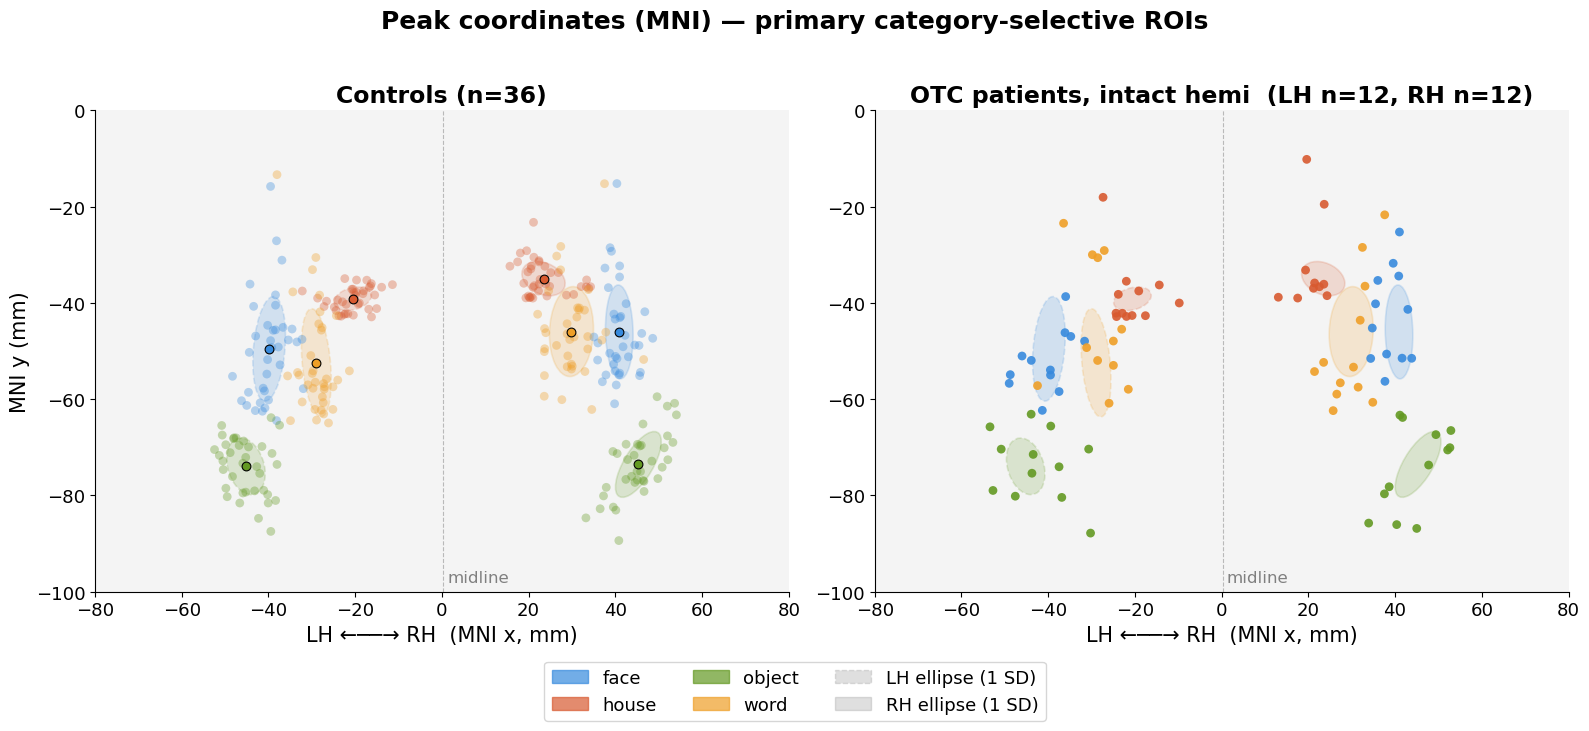

In [5]:
# 3b. Peak coords plot — primary ROIs
CATS_PRIMARY = [
    ('face_FFA',         '#378ADD', 'face'),
    ('house_PPA_strict', '#D85A30', 'house'),
    ('object_LOC',       '#639922', 'object'),
    ('word_VWFA',        '#EF9F27', 'word'),
]
n_lh = sum(1 for s in pt_subs_mni if intact(s) == 'l')
n_rh = sum(1 for s in pt_subs_mni if intact(s) == 'r')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=40, edgecolors='none', zorder=2)
                ax.scatter(x.mean(), y.mean(), color=color, s=40, edgecolors='black',
                           linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40, edgecolors='none', alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=12, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←──→ RH  (MNI x, mm)', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=15)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=17, fontweight='bold')
    else:
        ax.set_title(f'OTC patients, intact hemi  (LH n={n_lh}, RH n={n_rh})',
                     fontsize=17, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)')]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

cols present: True True
house parcels: ['house_PPA', 'house_PPA_strict', 'house_TOS']


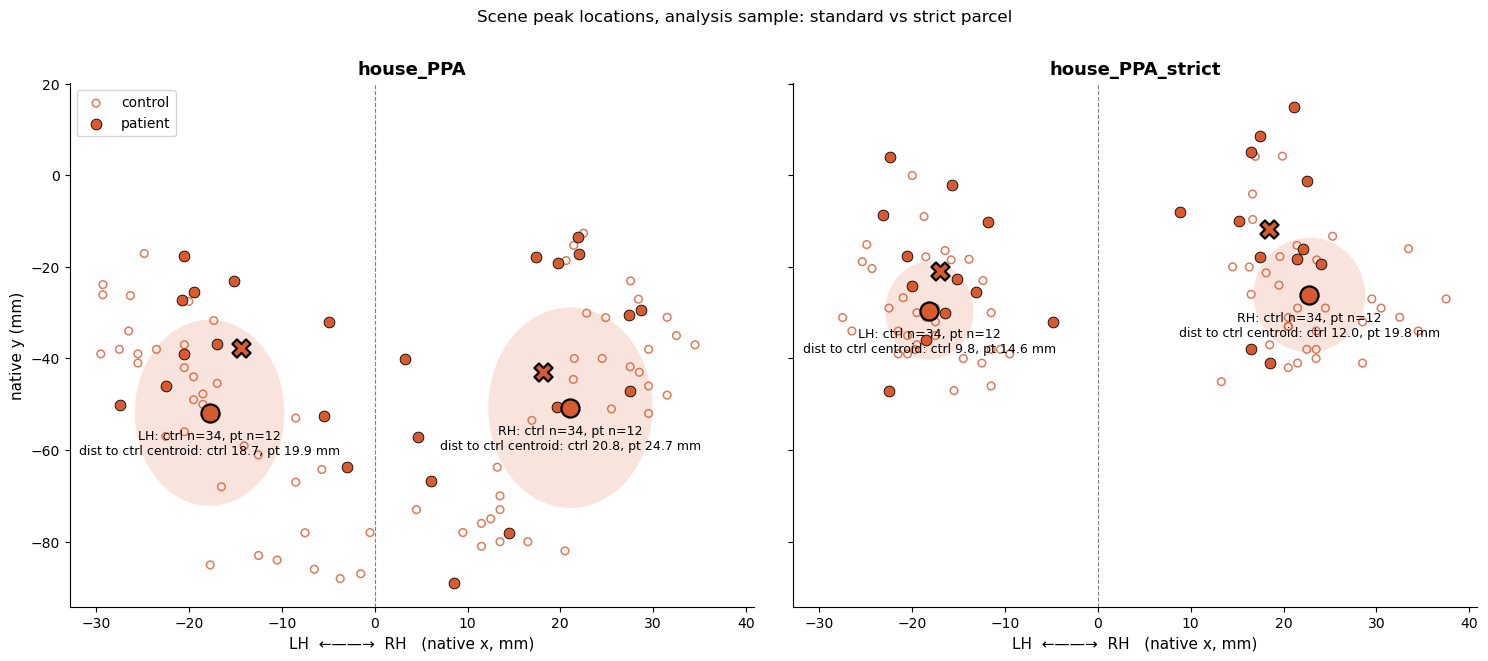

In [6]:
# ─── house_PPA vs house_PPA_strict: peak locations (analysis sample) ──────
from matplotlib.patches import Ellipse

PEAK_SRC = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized.csv')
PEAK_SRC = PEAK_SRC[~PEAK_SRC['subject_id'].isin(EXCLUDE)].copy()
PEAK_SRC['ses_num'] = pd.to_numeric(PEAK_SRC['session'], errors='coerce')
for s, se in EXCLUDE_SES:
    PEAK_SRC = PEAK_SRC[~((PEAK_SRC['subject_id'] == s) & (PEAK_SRC['ses_num'] == se))]
_c = PEAK_SRC[PEAK_SRC['status'] == 'control']
_c = _c[_c['ses_num'] == _c.groupby('subject_id')['ses_num'].transform('min')]
_p = PEAK_SRC[PEAK_SRC['group'] == 'OTC']
_p = _p[_p['ses_num'] == _p.groupby('subject_id')['ses_num'].transform('max')]
_p = _p[((_p['intact_hemi'] == 'left') & (_p['hemi'] == 'l')) |
        ((_p['intact_hemi'] == 'right') & (_p['hemi'] == 'r'))]
peaks = pd.concat([_c, _p], ignore_index=True)

XC, YC = 'peak_x_native', 'peak_y_native'
print('cols present:', XC in peaks.columns, YC in peaks.columns)
print('house parcels:', sorted(x for x in peaks['category'].unique() if 'house' in str(x)))

PARCELS = ['house_PPA', 'house_PPA_strict']
PC = CAT_COLORS['house']
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)

for ax, parcel in zip(axes, PARCELS):
    for hemi, hlab in [('l', 'LH'), ('r', 'RH')]:
        cs = peaks[(peaks.category == parcel) & (peaks.hemi == hemi) & (peaks.status == 'control')]
        ps = peaks[(peaks.category == parcel) & (peaks.hemi == hemi) & (peaks.group == 'OTC')]
        if not len(cs):
            continue
        cx, cy = cs[XC].values, cs[YC].values
        px, py = ps[XC].values, ps[YC].values
        ax.scatter(cx, cy, s=30, facecolors='none', edgecolors=PC, linewidths=1.1,
                   alpha=0.8, zorder=3, label='control' if hemi == 'l' else None)
        ax.scatter(px, py, s=60, color=PC, edgecolors='black', linewidths=0.6,
                   zorder=4, label='patient' if hemi == 'l' else None)
        if len(cx) > 2:
            ax.add_patch(Ellipse((cx.mean(), cy.mean()), 2*cx.std(ddof=1), 2*cy.std(ddof=1),
                                 facecolor=PC, alpha=0.16, zorder=1))
        ax.scatter([cx.mean()], [cy.mean()], s=170, marker='o', color=PC,
                   edgecolors='black', linewidths=1.6, zorder=6)
        if len(px):
            ax.scatter([px.mean()], [py.mean()], s=170, marker='X', color=PC,
                       edgecolors='black', linewidths=1.6, zorder=6)
            c0 = np.array([cx.mean(), cy.mean()])
            cd = np.hypot(cx - c0[0], cy - c0[1])
            pdd = np.hypot(px - c0[0], py - c0[1])
            ax.annotate(f'{hlab}: ctrl n={len(cx)}, pt n={len(px)}\n'
                        f'dist to ctrl centroid: ctrl {cd.mean():.1f}, pt {pdd.mean():.1f} mm',
                        xy=(cx.mean(), cy.mean()), xytext=(0, -30),
                        textcoords='offset points', ha='center', fontsize=9)
    ax.axvline(0, color='gray', ls='--', lw=0.8)
    ax.set_title(parcel, fontsize=13, fontweight='bold')
    ax.set_xlabel('LH  ←——→  RH   (native x, mm)', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('native y (mm)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10)
fig.suptitle('Scene peak locations, analysis sample: standard vs strict parcel',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ppa_parcel_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ─── Is altered geometry spatially local to rVWFA? ───────────────────────
# Tests the adjacency account: if word selectivity expands in the intact RH,
# the ROIs showing altered geometry should be the ones nearest rVWFA.
XC, YC, ZC = 'peak_x_native', 'peak_y_native', 'peak_z_native'
ROIS4 = ['face_FFA', 'house_PPA', 'house_PPA_strict', 'object_LOC', 'word_VWFA']

src = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized.csv')
src = src[~src['subject_id'].isin(EXCLUDE)].copy()
src['ses_num'] = pd.to_numeric(src['session'], errors='coerce')
for s, se in EXCLUDE_SES:
    src = src[~((src['subject_id'] == s) & (src['ses_num'] == se))]

_c = src[src['status'] == 'control']
_c = _c[_c['ses_num'] == _c.groupby('subject_id')['ses_num'].transform('min')]
_p = src[src['group'] == 'OTC']
_p = _p[_p['ses_num'] == _p.groupby('subject_id')['ses_num'].transform('max')]
_p = _p[((_p['intact_hemi'] == 'left') & (_p['hemi'] == 'l')) |
        ((_p['intact_hemi'] == 'right') & (_p['hemi'] == 'r'))]

def centroid(df, roi, hemi):
    d = df[(df['category'] == roi) & (df['hemi'] == hemi)]
    if not len(d):
        return None
    return np.array([d[XC].mean(), d[YC].mean(), d[ZC].mean()])

for hemi, hlab in [('r', 'RH'), ('l', 'LH')]:
    print(f'\n=== {hlab} — distance from each ROI to VWFA centroid (mm) ===')
    for grp, gdf in [('control', _c), ('patient', _p)]:
        ref = centroid(gdf, 'word_VWFA', hemi)
        if ref is None:
            print(f'  {grp}: no VWFA rows'); continue
        print(f'  {grp}  (VWFA at [{ref[0]:.0f}, {ref[1]:.0f}, {ref[2]:.0f}])')
        rows = []
        for roi in ROIS4:
            if roi == 'word_VWFA':
                continue
            c = centroid(gdf, roi, hemi)
            if c is None:
                rows.append((roi, np.nan)); continue
            rows.append((roi, float(np.linalg.norm(c - ref))))
        for roi, dist in sorted(rows, key=lambda r: (np.isnan(r[1]), r[1])):
            print(f'    {roi:<20} {dist:6.1f}')

# geometry omnibus alongside, so distance and effect sit in one view
print('\n=== RH geometry omnibus (standard run) ===')
g = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results_harmonized_corrected.csv')
g = g[(g['measure'] == 'geometry') & (g['level'] == 'ALL') &
      (g['model'].astype(str).str.contains('RH-intact'))]
print(g[['model', 'omnibus_chi2', 'omnibus_p']].round(4).to_string(index=False))


=== RH — distance from each ROI to VWFA centroid (mm) ===
  control  (VWFA at [29, -35, -6])
    face_FFA               10.9
    house_PPA_strict       11.5
    house_PPA              17.5
    object_LOC             30.6
  patient  (VWFA at [27, -31, -4])
    face_FFA                9.8
    house_PPA              15.9
    house_PPA_strict       21.1
    object_LOC             29.8

=== LH — distance from each ROI to VWFA centroid (mm) ===
  control  (VWFA at [-26, -41, -6])
    face_FFA               11.1
    house_PPA              14.1
    house_PPA_strict       14.4
    object_LOC             25.9
  patient  (VWFA at [-24, -26, -14])
    house_PPA_strict       10.2
    face_FFA               12.6
    house_PPA              16.0
    object_LOC             31.9

=== RH geometry omnibus (standard run) ===
                                model  omnibus_chi2  omnibus_p
        face_FFA_RH-intact_pt_vs_ctrl       40.7621     0.0000
house_PPA_strict_RH-intact_pt_vs_ctrl       14.0132     0

## 4. WTA composition bars (LH-/RH-intact) — q-stars from `stats_results.csv`

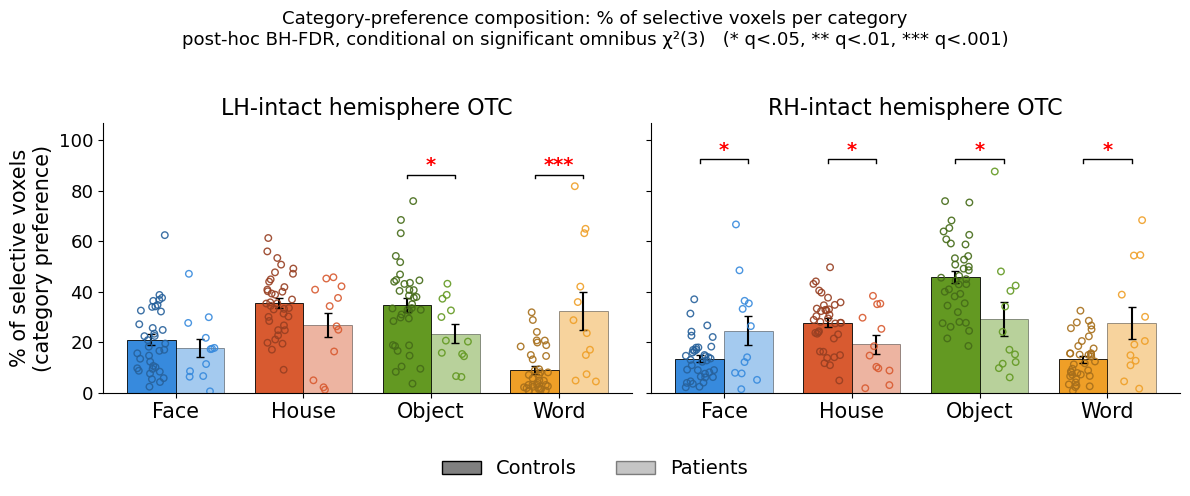

In [8]:
import matplotlib.colors as mcolors

WTA_CSV = '/user_data/csimmon2/sym_pt/group_results/wta_percentages.csv'
MODEL_FOR_HEMI = {'l': 'M1_LH_ctrl_vs_pt', 'r': 'M2_RH_ctrl_vs_pt'}

def darken(c, f=0.70):
    r, g, b = mcolors.to_rgb(c)
    return (r*f, g*f, b*f)

def _stars(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

wta = pd.read_csv(WTA_CSV)
wta = wta[(wta['region'] == 'otc') & (wta['denominator'] == 'selective')].copy()
wta = wta[~wta['subject_id'].isin(EXCLUDE)]
wta['ses_num'] = pd.to_numeric(wta['session'], errors='coerce').astype('Int64')
for s, se in EXCLUDE_SES:
    wta = wta[~((wta['subject_id'] == s) & (wta['ses_num'] == se))]
_c = wta[wta['status'] == 'control']
_c = _c.merge(_c.groupby('subject_id')['ses_num'].min().rename('k').reset_index(), on='subject_id')
_c = _c[_c['ses_num'] == _c['k']].drop(columns='k')
_p = wta[wta['group'] == 'OTC']
_p = _p.merge(_p.groupby('subject_id')['ses_num'].max().rename('k').reset_index(), on='subject_id')
_p = _p[_p['ses_num'] == _p['k']].drop(columns='k')
wta = pd.concat([_c, _p], ignore_index=True)

stats = pd.read_csv(STATS_CSV)
sw = stats[(stats['measure'] == 'wta') & (stats['comparison'] == 'patient_vs_control')]
qmap = {}
for hemi, model in MODEL_FOR_HEMI.items():
    for _, r in sw[sw['model'] == model].iterrows():
        qmap[(hemi, r['level'])] = r['q_fdr']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(CATEGORIES)); w = 0.38
RNG = np.random.RandomState(0)
for ax, h, hlabel in zip(axes, ['l', 'r'], ['LH-intact', 'RH-intact']):
    sub = wta[wta['hemi'] == h]
    max_top = 0
    for offset, grp, alpha in [(-w/2, 'control', 1.0), (+w/2, 'OTC', 0.45)]:
        means, sems = [], []
        for c in CATEGORIES:
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct']
            means.append(vals.mean()); sems.append(vals.sem())
        ax.bar(x + offset, means, w, yerr=sems, color=[CAT_COLORS[c] for c in CATEGORIES],
               alpha=alpha, edgecolor='black', linewidth=0.6, capsize=3, zorder=2)
        for xi, c in enumerate(CATEGORIES):
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct'].values
            ecol = darken(CAT_COLORS[c]) if grp == 'control' else CAT_COLORS[c]
            jit = (RNG.rand(len(vals)) - 0.5) * (w * 0.6)
            ax.scatter(xi + offset + jit, vals, s=22, facecolors='none',
                       edgecolors=ecol, linewidths=1.0, alpha=0.9, zorder=3)
            if len(vals): max_top = max(max_top, vals.max())
    by, bh = max_top * 1.04, max_top * 0.015
    for xi, c in enumerate(CATEGORIES):
        s = _stars(qmap.get((h, c), np.nan))
        if not s: continue
        xl, xr = xi - w/2, xi + w/2
        ax.plot([xl, xl, xr, xr], [by, by+bh, by+bh, by], color='black', lw=1, zorder=4)
        ax.text(xi, by+bh, s, ha='center', va='bottom', color='red',
                fontsize=14, fontweight='bold', zorder=4)
    ax.set_ylim(0, max_top * 1.22)
    ax.set_xticks(x); ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=15)
    ax.set_title(f'{hlabel} hemisphere OTC', fontsize=16)
    if h == 'l':
        ax.set_ylabel('% of selective voxels\n(category preference)', fontsize=15)
    ax.tick_params(axis='y', labelsize=13)
fig.legend(handles=[Patch(facecolor='gray', edgecolor='black', label='Controls'),
                    Patch(facecolor='gray', alpha=0.45, edgecolor='black', label='Patients')],
           ncol=2, frameon=False, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, -0.1))
fig.suptitle('Category-preference composition: % of selective voxels per category\n'
             'post-hoc BH-FDR, conditional on significant omnibus χ²(3)   '
             '(* q<.05, ** q<.01, *** q<.001)', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig(FIG_DIR / 'catpref_composition_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Sensitivity check (NOT a replacement for reported q): closure-aware CLR re-test
from scipy.stats import mannwhitneyu
EPS = 0.5  # % pseudocount so zero-share categories can be logged

def clr_by_subject(df_h):
    out = {}
    for sid, g in df_h.groupby('subject_id'):
        comp = np.array([g[g['category'] == c]['wta_pct'].mean() for c in CATEGORIES], float)
        comp = np.nan_to_num(comp, nan=0.0) + EPS
        lg = np.log(comp)
        out[sid] = lg - lg.mean()          # CLR
    return out

print(f"{'hemi':<5}{'category':<9}{'FDR (raw %)':<13}{'CLR p (MW, unc.)':<16}")
for h in ('l', 'r'):
    sub = wta[wta['hemi'] == h]
    Cc = np.array(list(clr_by_subject(sub[sub['group'] == 'control']).values()))
    Cp = np.array(list(clr_by_subject(sub[sub['group'] == 'OTC']).values()))
    for i, c in enumerate(CATEGORIES):
        _, p = mannwhitneyu(Cc[:, i], Cp[:, i], alternative='two-sided')
        raw = _stars(qmap.get((h, c), np.nan)) or 'ns'
        print(f"{h:<5}{c:<9}{raw:<13}{p:<16.3f}")

hemi category FDR (raw %)  CLR p (MW, unc.)
l    face     ns           0.300           
l    house    ns           0.023           
l    object   *            0.049           
l    word     ***          0.001           
r    face     *            0.194           
r    house    *            0.049           
r    object   *            0.006           
r    word     *            0.028           


## 5. Sum-selectivity & distinctiveness (shared style)
Box/violin toggle via `PLOT_KIND`. Controls = solid category color, patients = translucent. q read from `stats_results.csv`.

In [10]:
PLOT_KIND = 'box'   # 'box' or 'violin'
CTRL_A, PT_A = 0.9, 0.3            # control solid, patient translucent
HOUSE_ROI = 'house_PPA_strict'     # primary house parcel; 'house_PPA' for the wide version
CAT_PRIMARY = {'face': 'face_FFA', 'house': HOUSE_ROI,
               'object': 'object_LOC', 'word': 'word_VWFA'}
CATS_PANEL = ['face', 'house', 'object', 'word']
_stats_df = pd.read_csv(STATS_CSV)

def stars_from_q(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

def q_for(measure, cat, h):
    m = _stats_df[(_stats_df['measure'] == measure) &
                  (_stats_df['comparison'] == 'patient_vs_control') &
                  (_stats_df['level'] == CAT_PRIMARY[cat]) & (_stats_df['hemi'] == h)]
    return float(m['q_fdr'].iloc[0]) if len(m) else np.nan

def draw_dist(ax, vals, pos, col, alpha, width=0.5):
    if len(vals) < 2: return
    if PLOT_KIND == 'violin':
        parts = ax.violinplot([vals], positions=[pos], widths=width,
                              showmeans=False, showmedians=False, showextrema=False)
        for b in parts['bodies']:
            b.set_facecolor(col); b.set_alpha(alpha); b.set_edgecolor(col)
    else:
        bp = ax.boxplot([vals], positions=[pos], widths=width, patch_artist=True,
                        showfliers=False, manage_ticks=False, zorder=2)
        for box in bp['boxes']:
            box.set_facecolor(col); box.set_alpha(alpha); box.set_edgecolor(col)
        for el in ('whiskers', 'caps'):
            for ln in bp[el]:
                ln.set_color(col)
        for ln in bp['medians']:
            ln.set_color('black')

def build_primary_table(df, subjects, value_col, log10=False):
    rows = []
    for s in subjects:
        for cat in CAT_PRIMARY:
            for h in ('l', 'r'):
                m = df[(df['subject_id'] == s) & (df['category'] == CAT_PRIMARY[cat]) &
                       (df['hemi'] == h)].drop_duplicates(subset=['subject_id', 'category', 'hemi'])
                v = m[value_col].dropna().values
                if log10:
                    v = v[v > 0]
                    val = np.mean(np.log10(v)) if len(v) else np.nan
                else:
                    val = np.mean(v) if len(v) else np.nan
                if not np.isnan(val):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': val})
    return pd.DataFrame(rows)

def plot_primary_panel(measure, value_col, ylabel, fname, suptitle,
                       log10=False, y0=None, ctrl_df=None, pt_df=None,
                       legend_loc='upper left'):
    if ctrl_df is None or pt_df is None:
        raise ValueError('pass ctrl_df and pt_df explicitly (harmonized frames); '
                         'no fallback to ctrl_le/pt_le, which come from '
                         'liu_exact_replication_v2.csv and carry a different cohort')
    ctrl_subjects = sorted(ctrl_df['subject_id'].unique())
    pt_subjects   = sorted(pt_df['subject_id'].unique())
    ctrl_t = build_primary_table(ctrl_df, ctrl_subjects, value_col, log10)
    pt_t   = build_primary_table(pt_df,   pt_subjects,   value_col, log10)
    intact_lookup = dict(zip(pt_df['subject_id'], pt_df['intact_hemi']))
    pt_t['intact_hemi'] = pt_t['subject_id'].map(intact_lookup)
    pt_t = pt_t[((pt_t['intact_hemi'] == 'left') & (pt_t['hemi'] == 'l')) |
                ((pt_t['intact_hemi'] == 'right') & (pt_t['hemi'] == 'r'))]

    INTRA, INTER, CAT_GAP = 0.55, 0.7, 1.0
    pos_w = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]; cat_width = pos_w[-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    rng = np.random.RandomState(42); cat_centers = []
    allv = np.concatenate([ctrl_t['val'].dropna().values, pt_t['val'].dropna().values])
    gmax, gmin = np.nanmax(allv), np.nanmin(allv); brack_h = (gmax - gmin) * 0.02
    for ci, cat in enumerate(CATS_PANEL):
        col = CAT_COLORS[cat]; base = ci * (cat_width + CAT_GAP)
        positions = [base + p for p in pos_w]; cat_centers.append(np.mean(positions))
        cl = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'l')]['val'].values
        cr = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'r')]['val'].values
        pl = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'l')]['val'].values
        pr = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'r')]['val'].values
        for vals, p, a in [(cl, positions[0], CTRL_A), (pl, positions[1], PT_A),
                           (cr, positions[2], CTRL_A), (pr, positions[3], PT_A)]:
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0: continue
            draw_dist(ax, vals, p, col, a)
            jit = rng.uniform(-0.09, 0.09, len(vals))
            ax.scatter(np.full(len(vals), p) + jit, vals, facecolors=col, alpha=0.7,
                       s=18, edgecolors='black', linewidths=0.4, zorder=3)
        for (h, x_l, x_r) in [('l', positions[0], positions[1]), ('r', positions[2], positions[3])]:
            s = stars_from_q(q_for(measure, cat, h))
            if not s: continue
            by = gmax + brack_h * 2
            ax.plot([x_l, x_l, x_r, x_r], [by, by+brack_h, by+brack_h, by],
                    color='black', lw=1, zorder=6)
            ax.text((x_l + x_r) / 2, by + brack_h, s, ha='center', va='bottom',
                    color='red', fontsize=13, fontweight='bold', zorder=6)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=14); ax.tick_params(axis='y', labelsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for cat, center in zip(CATS_PANEL, cat_centers):
        ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
                color=CAT_COLORS[cat], ha='center', va='top',
                transform=ax.get_xaxis_transform())
    tw = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
    ax.set_xlim(-0.35, tw + 0.35); ax.margins(x=0.005)
    yr = gmax - gmin
    lo = y0 if y0 is not None else gmin - 0.04 * yr
    ax.set_ylim(lo, gmax + 0.14 * yr)
    ax.legend(handles=[Patch(facecolor='gray', alpha=CTRL_A, label='Control'),
                       Patch(facecolor='gray', alpha=PT_A, label='Patient (intact hemi)')],
              loc=legend_loc, fontsize=11, frameon=True, framealpha=0.9)
    plt.suptitle(suptitle, fontsize=13, fontweight='bold', y=0.99)
    plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

# Which (measure, level, hemi) stars will resolve from STATS_CSV, given CAT_PRIMARY.
for _m in ('sum_selectivity', 'distinctiveness'):
    _miss = [f'{c}/{h}' for c in CATS_PANEL for h in ('l', 'r')
             if np.isnan(q_for(_m, c, h))]
    print(f'{_m}: no q row for -> {_miss if _miss else "none"}')


sum_selectivity: no q row for -> none
distinctiveness: no q row for -> none


### 5a. Sum-selectivity (log10)

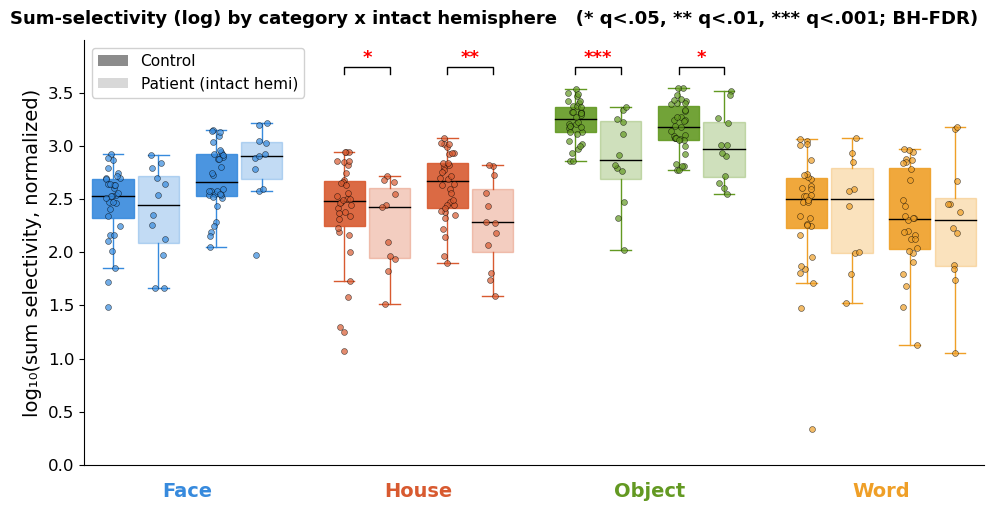

In [11]:
plot_primary_panel(
    measure='sum_selectivity', value_col='sum_selec_norm',
    ylabel='log₁₀(sum selectivity, normalized)',
    fname='sum_selectivity_primary.png',
    suptitle='Sum-selectivity (log) by category x intact hemisphere   '
             '(* q<.05, ** q<.01, *** q<.001; BH-FDR)',
    log10=True, y0=0.0, ctrl_df=ctrl_uni, pt_df=pt_uni)

### 5b. Distinctiveness (harmonized: rVWFA q=.034 → surviving star)

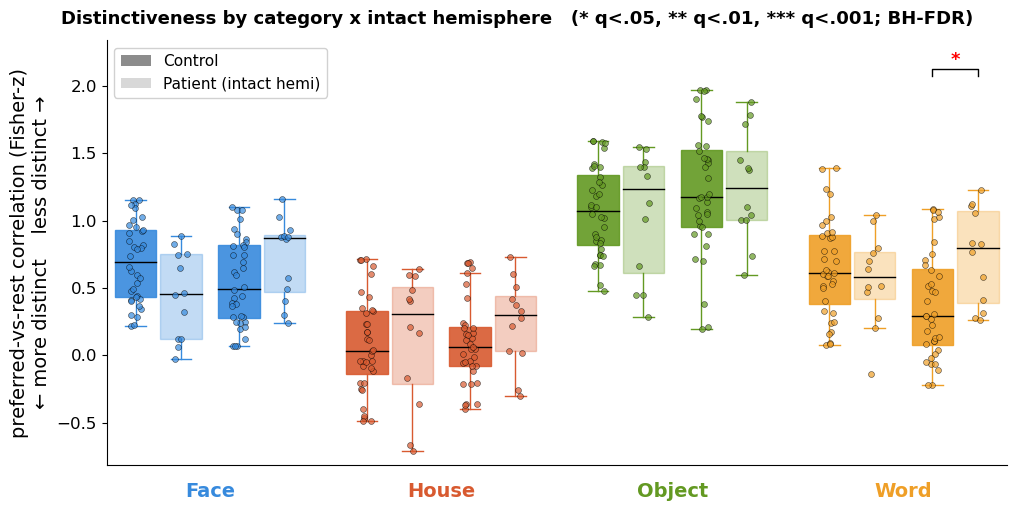

In [12]:
plot_primary_panel(
    measure='distinctiveness', value_col='liu_distinctiveness',
    ylabel='preferred-vs-rest correlation (Fisher-z)\n← more distinct    less distinct →',
    fname='distinctiveness_primary.png',
    suptitle='Distinctiveness by category x intact hemisphere   '
             '(* q<.05, ** q<.01, *** q<.001; BH-FDR)',
    log10=False, ctrl_df=ctrl_rsa, pt_df=pt_rsa)

## 6. WTA within-cluster composition (stacked)
Prereq cells (TFCE paths + `wta_data` builder) are included just below.

In [13]:
# ─── TFCE paths (prereq for stacked WTA) ─────────────────────────────────
import nibabel as nib
TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc_fdr'
print('TFCE_DIR:', TFCE_DIR, '| exists:', TFCE_DIR.exists())

TFCE_DIR: /user_data/csimmon2/sym_pt/group_results/tfce_votc_fdr | exists: True


In [14]:
# ─── WTA computation (Liu contrasts, per subject × hemi) ─────────────────
# Recomputes wta_data using SAME VOTC masks as tfce_votc_contrasts.py
# (loaded from TFCE_DIR/votc_{l,r}_mask.nii.gz) to ensure hemi labels
# match TFCE cluster files.

import os
from sym_pt_params import (skip_subs, get_sessions, is_patient,
                            get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word'] # note liu contrasts are all cat-vs-others, so same winner code (1) for all categories, not actual liu contrasts.
LIU_CONTRASTS = {'face': (6, False), 'house': (7, False),
                 'object': (8, False), 'word': (9, False)}
WTA_THRESHOLD = 2.326
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

# ── Load VOTC masks (same as TFCE script used) ───────────────────────
_lh_img = nib.load(TFCE_DIR / 'votc_l_mask.nii.gz')
VOTC_MASK_LH = _lh_img.get_fdata() > 0.5
VOTC_MASK_RH = nib.load(TFCE_DIR / 'votc_r_mask.nii.gz').get_fdata() > 0.5
MNI_AFFINE = _lh_img.affine
MNI_SHAPE  = _lh_img.shape
print(f'LH VOTC: {VOTC_MASK_LH.sum():,} | RH VOTC: {VOTC_MASK_RH.sum():,}')

# ── Subject loader ────────────────────────────────────────────────────
def load_subjects_xs():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        if f"{group}{sc}" in EXTRA_SKIP or sid in EXTRA_SKIP or group == 'nonOTC':
            continue
        post_sessions = [f'{s:02d}' for s in sessions
                         if f'{s:02d}' not in PRE_SURGERY_SESSIONS.get(sid, set())]
        if not post_sessions:
            continue
        subjects[sid] = {
            'session': post_sessions[0], 'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

# ── Compute WTA per subject × hemi ────────────────────────────────────
def _load_liu_zstats(sid, ses):
    vols = {}
    for cat, (cope, neg) in LIU_CONTRASTS.items():
        p = os.path.join(processed_dir, sid, f'ses-{ses}', 'derivatives', 'fsl',
                         'loc', 'HighLevel.gfeat', f'cope{cope}.feat', 'stats',
                         'zstat1_mni.nii.gz')
        if not os.path.exists(p):
            return None
        d = nib.load(p).get_fdata()
        vols[cat] = -d if neg else d
    return vols

def _compute_wta(vols, mask):
    z = np.stack([vols[c][mask] for c in CATEGORIES], axis=-1)
    max_z = z.max(axis=-1)
    winner = z.argmax(axis=-1) + 1
    winner[max_z < WTA_THRESHOLD] = 0
    sorted_z = np.sort(z, axis=-1)
    margin = sorted_z[:, -1] - sorted_z[:, -2]
    return winner, margin

subjects = load_subjects_xs()
ctrl_n = sum(1 for i in subjects.values() if i['group'] == 'control')
otc_n  = sum(1 for i in subjects.values() if i['group'] == 'OTC')
print(f'Subjects: {ctrl_n} ctrl + {otc_n} OTC')

wta_data, skipped = {}, []
for sid, info in subjects.items():
    vols = _load_liu_zstats(sid, info['session'])
    if vols is None:
        skipped.append(sid); continue
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
        winner, margin = _compute_wta(vols, mask)
        wta_data[(sid, h)] = {
            'winner': winner, 'margin': margin,
            'n_voxels': int(mask.sum()),
            'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
        }
print(f'WTA: {len(wta_data)} sub-hemi entries' + (f' | skipped: {skipped}' if skipped else ''))

LH VOTC: 11,340 | RH VOTC: 11,540
Subjects: 38 ctrl + 25 OTC
WTA: 101 sub-hemi entries


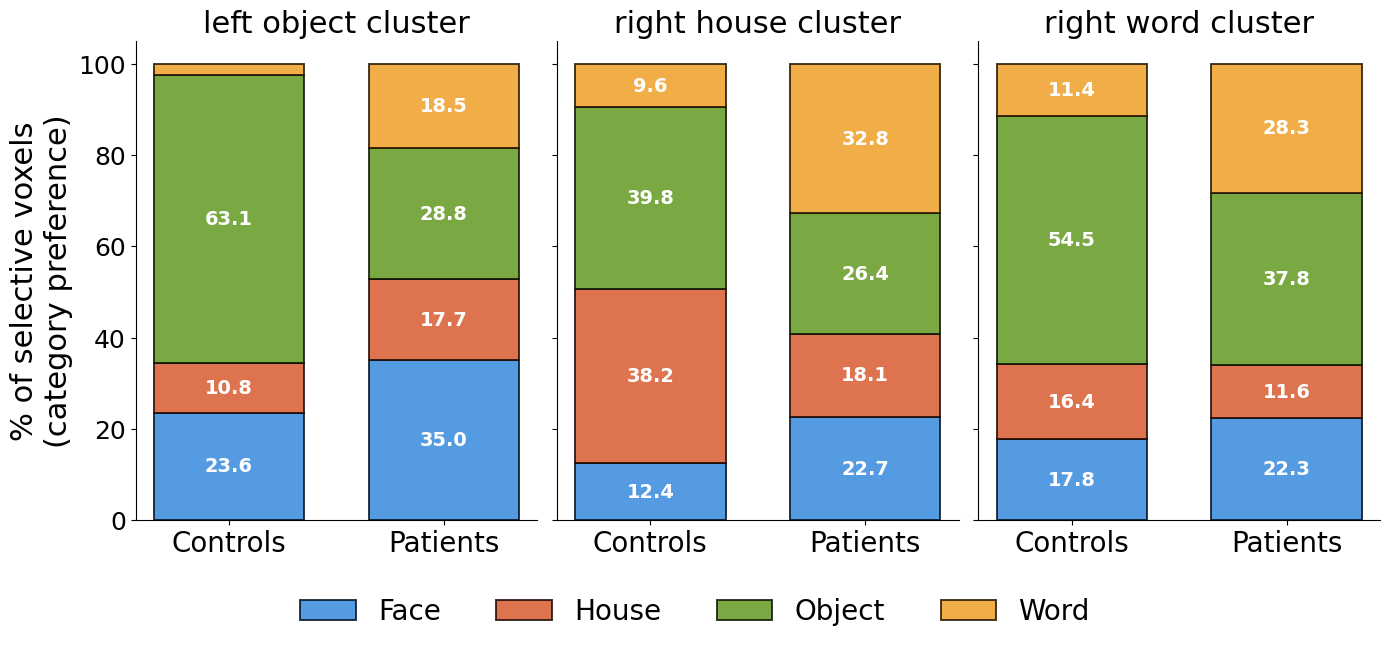

In [15]:
# ─── Category-preference composition bars (Liu-style, per cluster) ───────
# Composition normalized to selective voxels only.
import colorsys
BAR_ALPHA      = 0.85
EDGE_LINEWIDTH = 1.4
DARKEN_FACTOR  = 0.15
CLUSTERS = [
    ('object', 'l', 1, 'left object cluster'),
    ('house',  'r', 1, 'right house cluster'),
    ('word',   'r', 2, 'right word cluster'),
]

def darken_hls(hex_color, factor=DARKEN_FACTOR):
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(hex_color))
    return colorsys.hls_to_rgb(h, l * factor, s)

def composition_at_mask(group_label, hemi, cluster_3d_mask, hemi_3d_mask):
    cluster_in_hemi = cluster_3d_mask[hemi_3d_mask]
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, hh), d in wta_data.items():
        if hh != hemi or d['group'] != group_label:
            continue
        if len(d['winner']) != len(cluster_in_hemi):
            continue
        w = d['winner'][cluster_in_hemi]
        n = (w > 0).sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            per_cat[cat].append(100 * (w == i).sum() / n if n else np.nan)
    return {c: np.array(v) for c, v in per_cat.items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), sharey=True)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTERS):
    cluster_3d = nib.load(TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl' /
                          f'rand_tfce_corrp_tstat{tstat}.nii.gz').get_fdata() > 0.95
    hemi_3d    = nib.load(TFCE_DIR / f'votc_{hemi}_mask.nii.gz').get_fdata() > 0.5
    ctrl_comp = composition_at_mask('control', hemi, cluster_3d, hemi_3d)
    pt_comp   = composition_at_mask('OTC',     hemi, cluster_3d, hemi_3d)
    for xi, comp in zip([0, 1], [ctrl_comp, pt_comp]):
        bottom = 0
        for c in CATEGORIES:
            h = np.nanmean(comp[c])
            ax.bar(xi, h, bottom=bottom, width=0.7, facecolor=CAT_COLORS[c], alpha=BAR_ALPHA,
                   edgecolor=darken_hls(CAT_COLORS[c]), linewidth=EDGE_LINEWIDTH)
            if h >= 3:
                ax.text(xi, bottom + h/2, f'{h:.1f}', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold')
            bottom += h
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Controls', 'Patients'], fontsize=20)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 105); ax.set_title(title, fontsize=22)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[0].set_ylabel('% of selective voxels\n(category preference)', fontsize=22)
handles = [Patch(facecolor=CAT_COLORS[c], alpha=BAR_ALPHA, edgecolor=darken_hls(CAT_COLORS[c]),
                 linewidth=EDGE_LINEWIDTH, label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=20,
           loc='lower center', bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.savefig(FIG_DIR / 'catpref_within_cluster_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Procrustes / MDS configuration (geometry)
Prereq cells (RSA imports, `df`, helpers) are included just below. Note: this redefines `coords` for RSA — run after the peak cells.

In [16]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.spatial import procrustes
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

sys.path.insert(0, "/user_data/csimmon2/git_repos/sym_pt")
from sym_pt_params import processed_dir

np.random.seed(0)
MNI_CSV     = Path(processed_dir) / "group_results" / "peak_coords" / "peak_coords_mni.csv"
ROIS        = ["face_FFA", "house_PPA", "object_LOC", "word_VWFA"]
CATS4       = ["face", "object", "house", "word"]
N_PERM      = 10_000
HEMIS       = {"l": "left", "r": "right"}
EXCLUDE     = ['sub-017', 'sub-091', 'sub-095', 'sub-096', 'sub-027', 'sub-084']
EXCLUDE_SES = [('sub-108', 2)]

In [17]:
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni["subject_id"].isin(EXCLUDE)].copy()
mni["ses_num"] = pd.to_numeric(mni["session"], errors="coerce").astype("Int64")
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni["subject_id"] == bad_sub) & (mni["ses_num"] == bad_ses))]
mni = mni[mni["category"].isin(ROIS) & mni["pair"].notna()].copy()

ls = (mni[mni["group"]=="OTC"].groupby("subject_id")["ses_num"].max()
        .reset_index().rename(columns={"ses_num":"keep"}))
pt = mni[mni["group"]=="OTC"].merge(ls, on="subject_id"); pt = pt[pt["ses_num"]==pt["keep"]].drop(columns="keep")
fs = (mni[mni["status"]=="control"].groupby("subject_id")["ses_num"].min()
        .reset_index().rename(columns={"ses_num":"keep"}))
ct = mni[mni["status"]=="control"].merge(fs, on="subject_id"); ct = ct[ct["ses_num"]==ct["keep"]].drop(columns="keep")
df = pd.concat([pt, ct], ignore_index=True)

df["pair_sorted"] = df["pair"].apply(lambda p: "-".join(sorted(p.split("-"))))
PAIRS_SORTED = sorted(df["pair_sorted"].unique())
assert len(PAIRS_SORTED) == 6, f"expected 6 pairs, got {PAIRS_SORTED}"
df = df.drop(columns=["pair"])
df["is_pt"] = (df["status"] == "patient").astype(int)

print("patients:", df[df.is_pt==1]["subject_id"].nunique(), "| controls:", df[df.is_pt==0]["subject_id"].nunique())
print(df.groupby(["category","hemi","status"])["subject_id"].nunique().unstack(fill_value=0))

patients: 24 | controls: 36
status           control  patient
category   hemi                  
face_FFA   l          36       12
           r          36       12
house_PPA  l          36       12
           r          36       12
object_LOC l          36       12
           r          36       12
word_VWFA  l          36       12
           r          36       12


In [18]:
def stratum(df, roi, hemi):
    s = df[(df["category"] == roi) & (df["hemi"] == hemi)].copy()
    s["group"] = np.where(s["is_pt"] == 1, "patient", "control")
    return s

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return np.nan if sp == 0 else (np.mean(x) - np.mean(y)) / sp

def perm_test(x, y, n=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    obs = np.mean(x) - np.mean(y)
    pool = np.concatenate([x, y]); nx = len(x)
    null = np.empty(n)
    for i in range(n):
        rng.shuffle(pool); null[i] = np.mean(pool[:nx]) - np.mean(pool[nx:])
    return obs, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n + 1)

def bh_fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 1.0
    for k in range(m-1, -1, -1):
        i = order[k]; run = min(run, p[i] * m / (k+1)); adj[i] = run
    return adj

def subj_rdm(sub_rows):
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row["pair_sorted"].split("-"); i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row["fisher_r"])
    return M

def coords(sim_mat):
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity="precomputed", random_state=0
               ).fit_transform(1.0 - M)

def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s.group == grp].groupby("subject_id")
            if g["pair_sorted"].nunique() == 6}

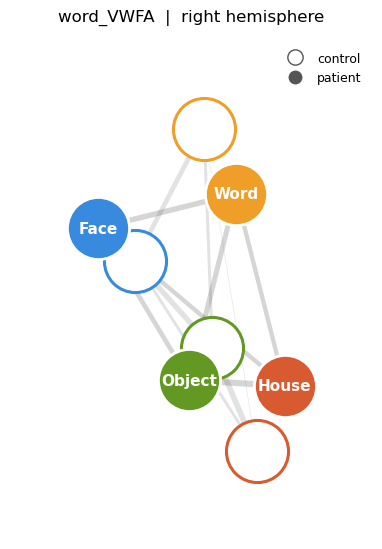

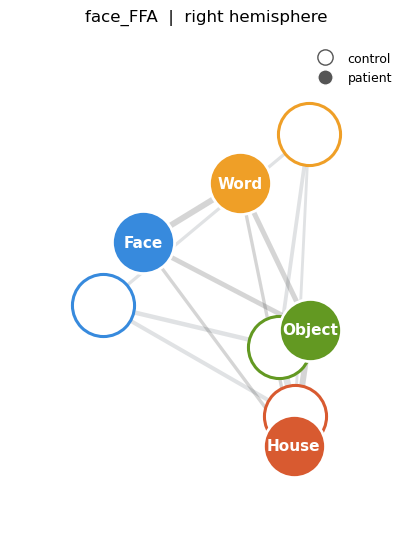

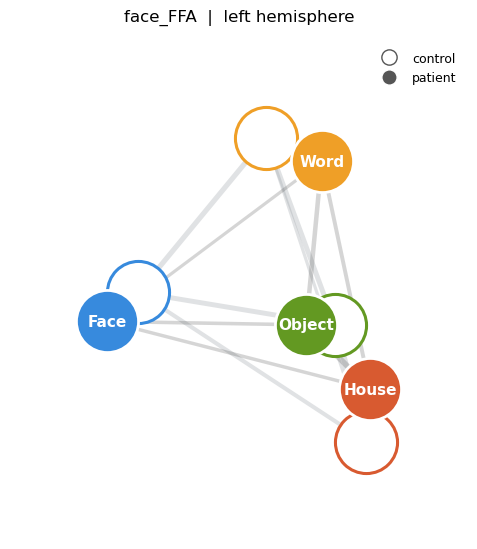

In [19]:
# ─── Procrustes/MDS configuration plots — selected ROI x hemi ────────────
PAIRS6 = [('face','object'),('face','house'),('face','word'),
          ('house','object'),('object','word'),('house','word')]

def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(coords(csim), coords(psim))
    return csim, psim, mtx1, mtx2

def plot_procrustes(roi, hemi):
    s = stratum(df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        return
    csim, psim, c_xy, p_xy = out
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i,0], c_xy[j,0]], [c_xy[i,1], c_xy[j,1]], color='#9aa0a6',
                lw=0.4 + r*5.5, alpha=0.30, solid_capstyle='round', zorder=1)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i,0], p_xy[j,0]], [p_xy[i,1], p_xy[j,1]], color='#444',
                lw=0.4 + r*5.5, alpha=0.22, solid_capstyle='round', zorder=2)
    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)
    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere', fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:,0].min()-pad, allxy[:,0].max()+pad)
    ax.set_ylim(allxy[:,1].min()-pad, allxy[:,1].max()+pad)
    legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

SELECTED = [("word_VWFA", "r"), ("face_FFA", "r"), ("face_FFA", "l")]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)

panels: ['VWFA', 'FFA', 'PPA', 'LO']
significant cells (q < .05): 5


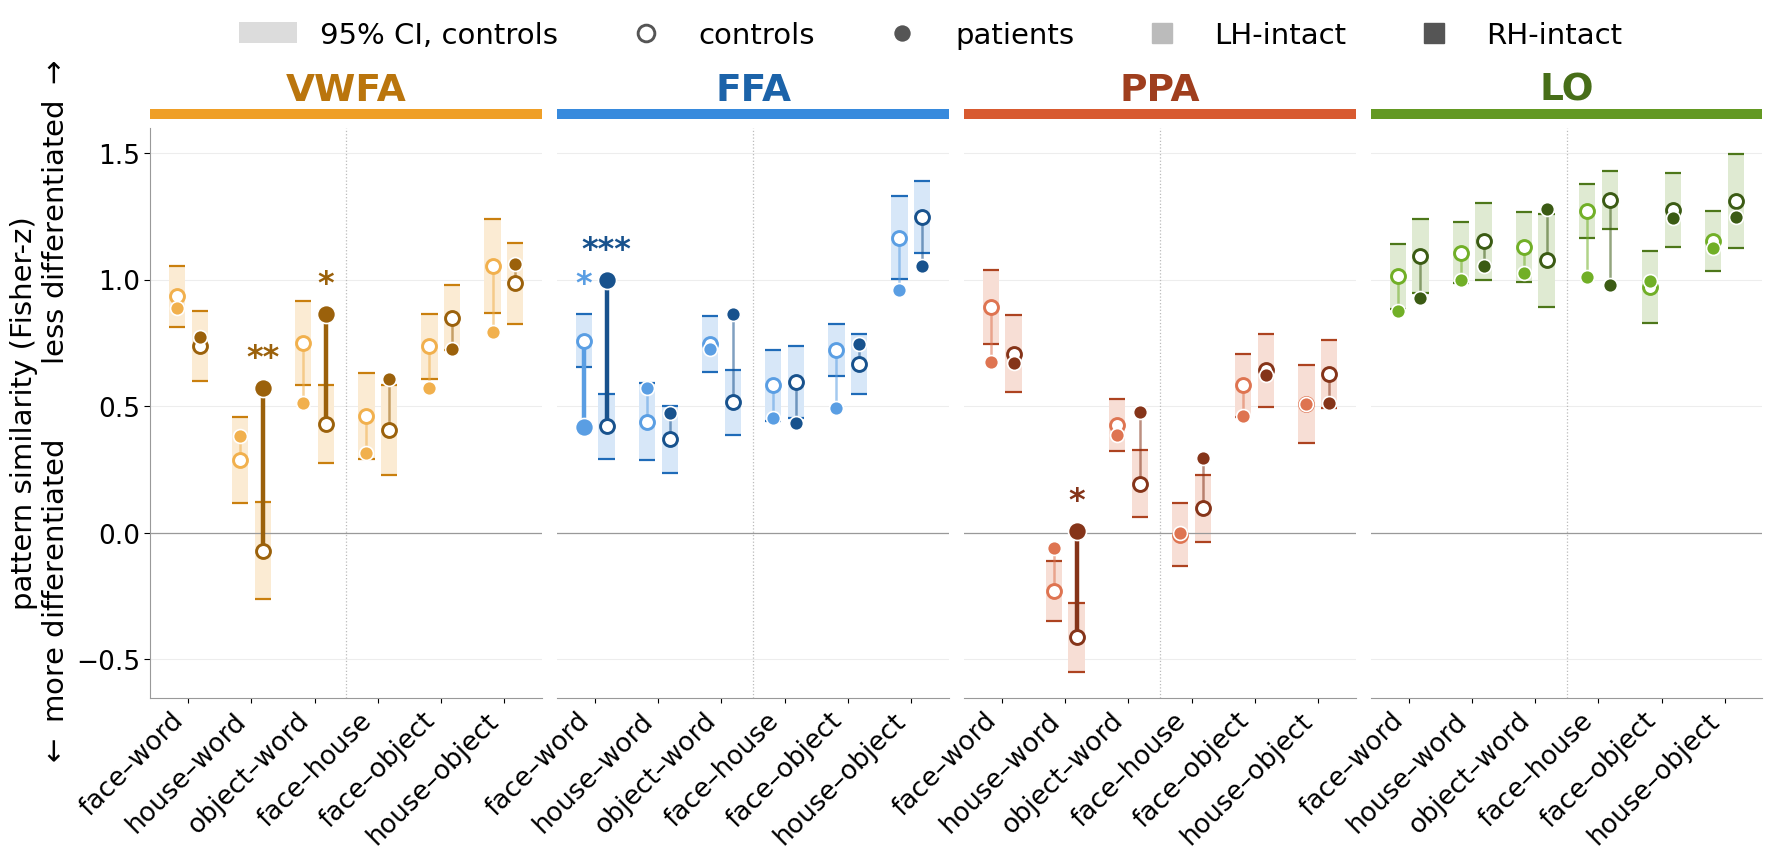

saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/between_category_similarity.png


In [20]:
# ─── 6. Between-category similarity ──────────────────────────────────────────
# One panel per ROI, fixed figure order VWFA, FFA, PPA, LO. x-axis = the six
# category pairs, word-containing pairs first.
#
# Per pair per intact hemisphere: a light band spanning the 95% CI of the
# control mean with darker caps at its ends, an open circle at that mean, and a
# line to a filled circle at the patient mean. Hemisphere is light vs dark
# marker plus x-offset.
#
# Panels are tightly spaced (wspace) so the text can be larger at the same
# overall width. Only the leftmost panel carries y tick labels.
#
# Raw Fisher-z: HIGHER = MORE similar = LESS differentiated. Zero = uncorrelated.
# No suptitle — FDR family and star thresholds go in the caption.

import colorsys

ROI_ORDER = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
ROI_TITLE = {'word_VWFA': 'VWFA', 'face_FFA': 'FFA',
             'house_PPA_strict': 'PPA', 'object_LOC': 'LO'}
ROI_CAT   = {'word_VWFA': 'word', 'face_FFA': 'face',
             'house_PPA_strict': 'house', 'object_LOC': 'object'}
PAIRS_ORDERED = ['face-word', 'house-word', 'object-word',
                 'face-house', 'face-object', 'house-object']

def _hex2rgb(h):
    h = h.lstrip('#')
    return [int(h[i:i + 2], 16) / 255 for i in (0, 2, 4)]

def _rgb2hex(r, g, b):
    return '#%02X%02X%02X' % (int(r * 255), int(g * 255), int(b * 255))

def _tint(hexc, f):
    r, g, b = _hex2rgb(hexc)
    return _rgb2hex(*[v + (1 - v) * f for v in (r, g, b)])

def _shade(hexc, f):
    r, g, b = _hex2rgb(hexc)
    hh, l, s = colorsys.rgb_to_hls(r, g, b)
    return _rgb2hex(*colorsys.hls_to_rgb(hh, max(0, min(1, l * f)), s))

def _stars(q):
    if q is None or pd.isna(q):
        return ''
    return '***' if q < .001 else '**' if q < .01 else '*' if q < .05 else ''

# ── q lookup ────────────────────────────────────────────────────────────────
_st = pd.read_csv(STATS_CSV)
_g = _st[(_st['measure'] == 'geometry') &
         (_st['comparison'] == 'patient_vs_control')].copy()

def _split_model(m):
    m = str(m)
    h = 'l' if 'LH-intact' in m else 'r'
    roi = (m.replace('_LH-intact_pt_vs_ctrl', '')
            .replace('_RH-intact_pt_vs_ctrl', ''))
    return roi, h

_g[['roi', 'ihemi']] = _g['model'].apply(lambda m: pd.Series(_split_model(m)))
Q_GEO = {(r.roi, r.level, r.ihemi): r.q_fdr for r in _g.itertuples()}

# ── subject-level Fisher-z, same cohort and sessions as ctrl_rsa / pt_rsa ────
_all = pd.read_csv(RSA_HARM)
_all = _all[~_all['subject_id'].isin(EXCLUDE)]
_all['ses_num'] = pd.to_numeric(_all['session'], errors='coerce').astype(int)
for _bs, _bse in EXCLUDE_SES:
    _all = _all[~((_all['subject_id'] == _bs) & (_all['ses_num'] == _bse))]
_keep_c = set(zip(ctrl_rsa['subject_id'], ctrl_rsa['ses_num']))
_keep_p = set(zip(pt_rsa['subject_id'], pt_rsa['ses_num']))
_c = _all[[t in _keep_c for t in zip(_all['subject_id'], _all['ses_num'])]]
_p = _all[[t in _keep_p for t in zip(_all['subject_id'], _all['ses_num'])]]
_p = _p[_p['hemi'] == _p['intact_hemi'].map({'left': 'l', 'right': 'r'})]

ROIS_GEO = [r for r in ROI_ORDER if r in set(_c['category'])]
print('panels:', [ROI_TITLE.get(r, r) for r in ROIS_GEO])
print('significant cells (q < .05):',
      sum(1 for v in Q_GEO.values() if pd.notna(v) and v < .05))

# ── plot ────────────────────────────────────────────────────────────────────
BAND_W = 0.13

fig, axes = plt.subplots(1, len(ROIS_GEO),
                         figsize=(5.2 * len(ROIS_GEO), 7.4), sharey=True,
                         gridspec_kw={'wspace': 0.04})
axes = np.atleast_1d(axes)
fig.patch.set_facecolor('white')

for i, (ax, roi) in enumerate(zip(axes, ROIS_GEO)):
    base = CAT_COLORS[ROI_CAT[roi]]
    band = _tint(base, 0.80)
    cap  = _shade(base, 0.78)
    col  = {'l': _shade(base, 1.15), 'r': _shade(base, 0.60)}
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#ededed', lw=0.8)
    ax.set_axisbelow(True)
    ax.axvline(2.5, color='#bbb', lw=0.9, ls=':')
    ax.axhline(0, color='#999', lw=0.9)
    for xi, pair in enumerate(PAIRS_ORDERED):
        for h in ('l', 'r'):
            off = -0.18 if h == 'l' else 0.18
            c = _c[(_c['category'] == roi) & (_c['pair'] == pair) &
                   (_c['hemi'] == h)]['fisher_r'].dropna()
            p = _p[(_p['category'] == roi) & (_p['pair'] == pair) &
                   (_p['hemi'] == h)]['fisher_r'].dropna()
            if len(c) < 3 or len(p) < 3:
                continue
            cm, pm = c.mean(), p.mean()
            cse = c.std(ddof=1) / np.sqrt(len(c))
            lo, hi = cm - 1.96 * cse, cm + 1.96 * cse
            x = xi + off
            q = Q_GEO.get((roi, pair, h))
            sig = pd.notna(q) and q < .05
            ax.add_patch(plt.Rectangle((x - BAND_W, lo), 2 * BAND_W, hi - lo,
                                       facecolor=band, edgecolor='none',
                                       zorder=1))
            for _y in (lo, hi):
                ax.plot([x - BAND_W, x + BAND_W], [_y, _y], color=cap,
                        lw=1.6, solid_capstyle='butt', zorder=2)
            ax.plot([x, x], [cm, pm], color=col[h],
                    lw=3.2 if sig else 1.8, alpha=1.0 if sig else 0.55,
                    solid_capstyle='round', zorder=3)
            ax.plot([x], [cm], 'o', ms=10, mfc='white', mec=col[h],
                    mew=2.1, zorder=4)
            ax.plot([x], [pm], 'o', ms=13 if sig else 10, color=col[h],
                    mec='white', mew=1.2, zorder=5)
            s = _stars(q)
            if s:
                ax.text(x, max(hi, pm) + 0.06, s, ha='center', va='bottom',
                        fontsize=23, color=col[h], fontweight='bold')
    ax.set_xticks(range(len(PAIRS_ORDERED)))
    ax.set_xticklabels([q.replace('-', '\u2013') for q in PAIRS_ORDERED],
                       rotation=45, ha='right', fontsize=19)
    ax.tick_params(axis='y', labelsize=19, length=4)
    ax.set_title(ROI_TITLE.get(roi, roi), fontsize=27, fontweight='bold',
                 color=_shade(base, 0.72), pad=20)
    ax.add_patch(plt.Rectangle((0.0, 1.015), 1.0, 0.017, color=base,
                               transform=ax.transAxes, clip_on=False, lw=0))
    ax.set_xlim(-0.6, len(PAIRS_ORDERED) - 0.4)
    ax.spines['left'].set_color('#999')
    ax.spines['bottom'].set_color('#999')
    if i > 0:                      # only the leftmost panel needs the axis
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('pattern similarity (Fisher-z)\n'
                   '$\\leftarrow$ more differentiated'
                   '        less differentiated $\\rightarrow$', fontsize=21)

handles = [Patch(facecolor='#dcdcdc', edgecolor='none', label='95% CI, controls'),
           Line2D([], [], marker='o', ls='', mfc='white', mec='#555',
                  mew=2.1, ms=12, label='controls'),
           Line2D([], [], marker='o', ls='', color='#555', ms=13,
                  mec='white', mew=1.2, label='patients'),
           Line2D([], [], marker='s', ls='', color='#bbb', ms=15, label='LH-intact'),
           Line2D([], [], marker='s', ls='', color='#555', ms=15, label='RH-intact')]
fig.legend(handles=handles, loc='upper center', frameon=False, ncol=5,
           bbox_to_anchor=(0.5, 1.06), fontsize=21)

fig.savefig(FIG_DIR / 'between_category_similarity.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved: {FIG_DIR / "between_category_similarity.png"}')

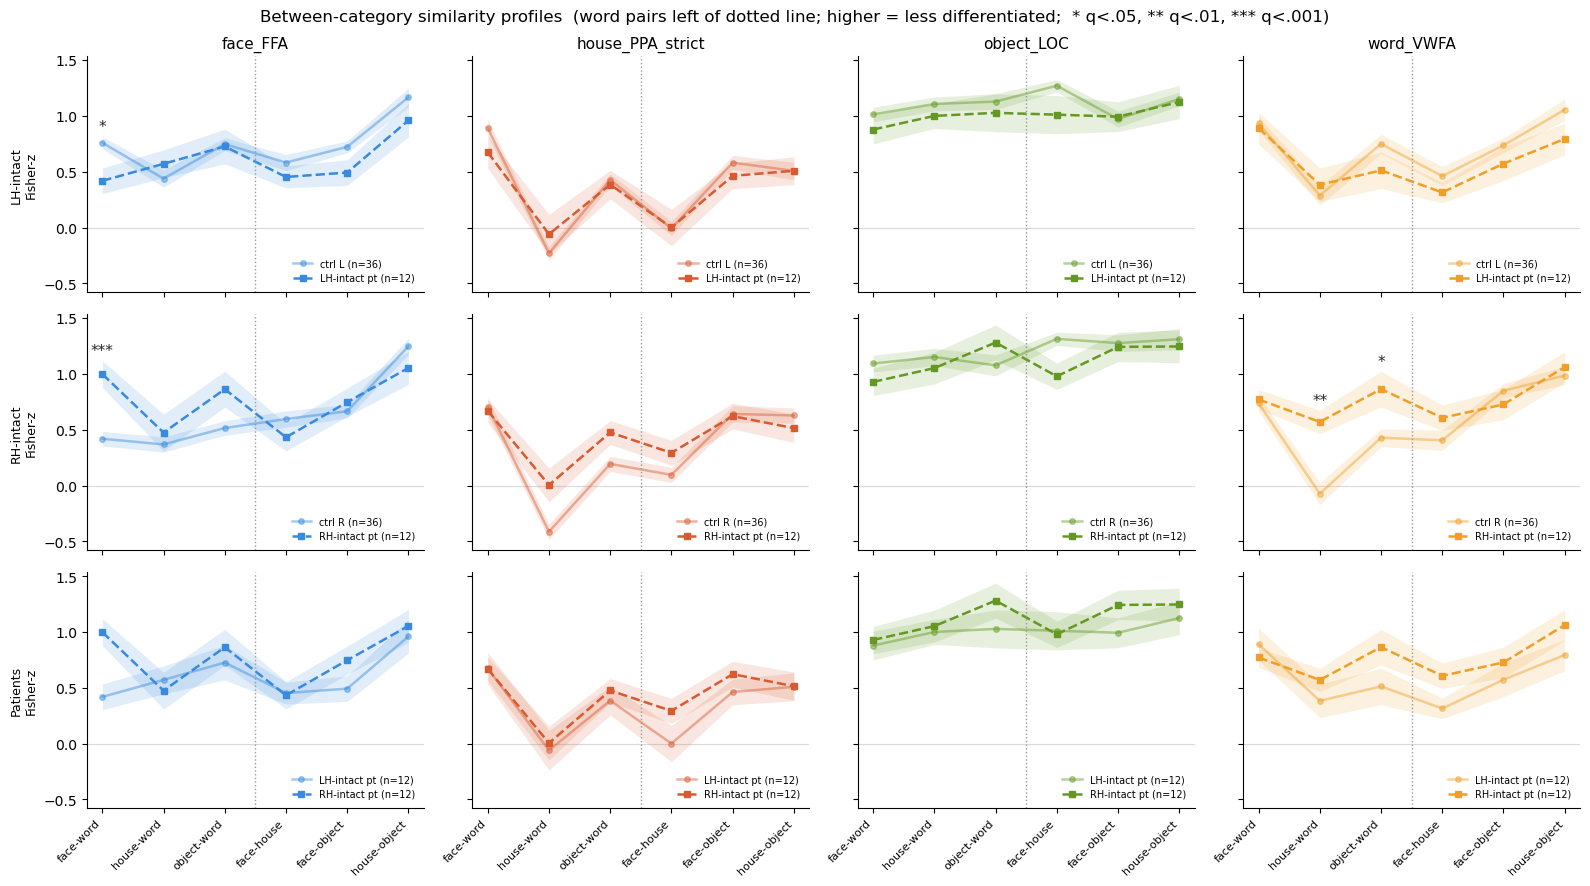

In [22]:
# ─── Between-category profiles: control vs patient, per ROI x hemisphere ──
RSA_HARM = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv')
PAIRS = ['face-word', 'house-word', 'object-word',
         'face-house', 'face-object', 'house-object']
ROIS_PROF = [('face_FFA', '#378ADD'), ('house_PPA_strict', '#D85A30'),
             ('object_LOC', '#639922'), ('word_VWFA', '#EF9F27')]
A_CTRL, A_PT = 0.45, 1.0        # line alpha only; patients darker

# Per-pair q, patients vs matched-hemisphere controls, gated on the ROI's
# significant pair x group interaction. Values as reported in the v3 draft.
QVALS = {
    ('LH-intact', 'face_FFA',   'face-word'):  .025,
    ('RH-intact', 'face_FFA',   'face-word'):  .0009,
    ('RH-intact', 'word_VWFA',  'house-word'): .005,
    ('RH-intact', 'word_VWFA',  'object-word'): .031,
}

_r = pd.read_csv(RSA_HARM)
_r = _r[~_r['subject_id'].isin(EXCLUDE)].copy()
_r['ses_num'] = pd.to_numeric(_r['session'], errors='coerce').astype(int)
for _s, _se in EXCLUDE_SES:
    _r = _r[~((_r['subject_id'] == _s) & (_r['ses_num'] == _se))]
_c = _r[_r['status'] == 'control']
_c = _c[_c['ses_num'] == _c.groupby('subject_id')['ses_num'].transform('min')]
_p = _r[_r['status'] == 'patient']
_p = _p[_p['ses_num'] == _p.groupby('subject_id')['ses_num'].transform('max')]

def _prof(d, roi):
    w = (d[d['category'] == roi]
         .pivot_table(index='subject_id', columns='pair', values='fisher_r')
         .reindex(columns=PAIRS))
    m = w.mean().values
    se = (w.std(ddof=1) / np.sqrt(w.notna().sum())).values
    return m, se, len(w)

x = np.arange(len(PAIRS))
ROWS = [('LH-intact', 'l', 'left'), ('RH-intact', 'r', 'right'), ('Patients', None, None)]

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True, sharey='all')
fig.patch.set_facecolor('white')

for j, (roi, color) in enumerate(ROIS_PROF):
    for i, (row_lab, hemi, intact) in enumerate(ROWS):
        ax = axes[i, j]
        if hemi is not None:
            series = [(_prof(_c[_c['hemi'] == hemi], roi), f'ctrl {hemi.upper()}', A_CTRL, '-', 'o'),
                      (_prof(_p[_p['intact_hemi'] == intact], roi), f'{row_lab} pt', A_PT, '--', 's')]
        else:
            series = [(_prof(_p[_p['intact_hemi'] == 'left'], roi), 'LH-intact pt', A_CTRL, '-', 'o'),
                      (_prof(_p[_p['intact_hemi'] == 'right'], roi), 'RH-intact pt', A_PT, '--', 's')]
        for (m, se, n), lab, a, ls, mk in series:
            ax.plot(x, m, ls, marker=mk, color=color, alpha=a, ms=4, lw=1.8,
                    label=f'{lab} (n={n})')
            ax.fill_between(x, m - se, m + se, color=color, alpha=0.15, lw=0)
        ax.axhline(0, color='0.85', lw=0.8, zorder=0)
        ax.axvline(2.5, ls=':', color='0.6', lw=1)
        for k, pr in enumerate(PAIRS):
            st = stars_from_q(QVALS.get((row_lab, roi, pr), np.nan))
            if st:
                hi = max(series[0][0][0][k] + series[0][0][1][k],
                         series[1][0][0][k] + series[1][0][1][k])
                ax.annotate(st, (k, hi), textcoords='offset points', xytext=(0, 4),
                            ha='center', fontsize=11, color='0.15')
        ax.legend(fontsize=7, frameon=False, loc='lower right')
        ax.spines[['top', 'right']].set_visible(False)
        if i == 0:
            ax.set_title(roi, fontsize=11)
        if j == 0:
            ax.set_ylabel(f'{row_lab}\nFisher-z', fontsize=9)
        if i == 2:
            ax.set_xticks(x)
            ax.set_xticklabels(PAIRS, rotation=45, ha='right', fontsize=8)

fig.suptitle('Between-category similarity profiles  (word pairs left of dotted line; '
             'higher = less differentiated;  * q<.05, ** q<.01, *** q<.001)', fontsize=12)
fig.tight_layout()
plt.show()